# analysis 02 - cooccurrence by host

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

In [3]:
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query('is_pab == True')
# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")
virus_hits_pvt = virus_hits.drop_duplicates(subset=['scientific_name', 'library'], keep='first')
bacteria_hits_pvt = bacteria_hits.drop_duplicates(subset=['scientific_name', 'library'], keep='first')

bacteria_hits_pvt['foo'] = 1
bacteria_hits_pvt = bacteria_hits_pvt.pivot(index='scientific_name', columns='library', values='foo').fillna(0)
virus_hits_pvt['foo'] = 1
virus_hits_pvt = virus_hits_pvt.pivot(index='scientific_name', columns='library', values='foo').fillna(0)

M = pd.concat([virus_hits_pvt, bacteria_hits_pvt]).fillna(0)
assert(len(M) == 158 + 127) # To check that we have the same number of bacteria  virus
# M.to_csv("scratch/adjmat.virusbact-library.csv", sep=';')

In [8]:
most_libraries_host = db.conn.sql('SELECT * FROM D_Sites').df().value_counts(['host_taxon']).reset_index().loc[0].host_taxon
most_libraries_host

'Convolvulus arvensis'

In [16]:
libraries = db.conn.sql("SELECT * FROM D_Sites WHERE host_taxon == 'Convolvulus arvensis'").df()['library'].to_list()

In [20]:
M_subset = M[libraries]
M_subset['total'] = M_subset.apply(lambda x: x.sum(), axis=1)
M_subset = M_subset.query('total > 0')
M_subset.drop(columns=['total']).to_csv(
    "scratch/adjmat.virusbact-library.C.arvensis.csv", sep=';'
)

/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_4431/3205259529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  M_subset['total'] = M_subset.apply(lambda x: x.sum(), axis=1)


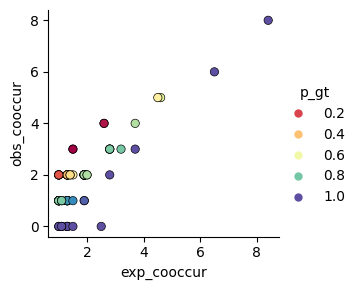

In [21]:
coocurrence_results = pd.read_csv(
    "scratch/coocurrence.virusbact-bylibrary.C.arvensis.csv", sep=',', index_col=0
)
bacteria_names = bacteria_hits['scientific_name'].to_list()
virus_names = virus_hits['scientific_name'].to_list()
name_kingdom_map = {}
for b in bacteria_names:
    name_kingdom_map[b] = 'Bacteria'
for v in virus_names:
    name_kingdom_map[v] = 'Virus'
coocurrence_results['sp1_kingdom'] = coocurrence_results['sp1_name'].map(name_kingdom_map)
coocurrence_results['sp2_kingdom'] = coocurrence_results['sp2_name'].map(name_kingdom_map)
coocurrence_results = coocurrence_results.dropna(subset=['sp1_name', 'sp2_name'])

sns.relplot(coocurrence_results, x='exp_cooccur', y='obs_cooccur', hue='p_gt', height=3.0, edgecolor='black', palette='Spectral')


In [ ]:
coocurrence_results.query('sp1_kingdom != sp2_kingdom').query('p_gt < 0.05 or p_lt < 0.05')

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom
75,20,21,7,5,0,0.179,2.5,0.01049,1.0,Rubus chlorotic mottle virus,Sweet potato chlorotic stunt virus RNA 1,Virus,Virus
